In [1]:
GROUP_NAME = "IowaGPT"
NAME = "Amit Boodhoo, Diego Liogon, Eva Singh, Kate Meyer"
PROJECT_NAME = "Project K"

In [ ]:
# imports
# Ensures matplotlib plots are displayed directly below the code cells in the notebook
%matplotlib inline
# Standard data science libraries for math, data manipulation, and visualization
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# Fixes a known local Anaconda environment conflict where multiple OpenMP 
# threading libraries load at the same time, preventing false "RuntimeWarnings".
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# Sklearn imports for classification
from sklearn import model_selection as skms
from sklearn import metrics
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Load the training and testing datasets
train_df = pd.read_csv('train_classification_dataset.csv') 
test_df = pd.read_csv('test_classification_dataset.csv')

# Display basic info to check for missing values and data types
print("---------------------Training Data Info---------------------")
train_df.info()

# show the first 5 rows of the training data
print("---------------------First 5 Rows of Training Dataset---------------------")
display(train_df.head())


---------------------Training Data Info---------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206310 entries, 0 to 206309
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   row_id                    206310 non-null  int64  
 1   participant_id            206310 non-null  int64  
 2   date                      206310 non-null  object 
 3   age                       206310 non-null  int64  
 4   gender                    206310 non-null  object 
 5   height_cm                 206310 non-null  float64
 6   weight_kg                 206310 non-null  float64
 7   duration_minutes          206310 non-null  float64
 8   intensity                 206310 non-null  object 
 9   daily_steps               206310 non-null  int64  
 10  avg_heart_rate            206310 non-null  int64  
 11  resting_heart_rate        206310 non-null  float64
 12  blood_pressure_systolic   206310 non-nu

,row_id,participant_id,date,age,gender,height_cm,weight_kg,duration_minutes,intensity,daily_steps,avg_heart_rate,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,sleep_hours,stress_level,hydration_level,smoking_status,health_condition,activity_type
0,269357,1174,2024/8/13,24,M,159.8,54.618789,123.9,Medium,7694,143,66.5,106.2,86.6,5.8,7,1.9,Never,NaN,Swimming
1,463873,2024,2024/1/31,45,F,152.8,52.965965,42.2,Low,9574,113,70.3,123.0,71.5,8.5,3,2.2,Never,NaN,Running
2,375177,1636,2024/10/19,60,F,159.4,57.671974,150.8,Low,5407,100,74.1,114.2,92.4,6.6,6,2.4,Former,NaN,Cycling
3,500598,2183,2024/3/5,51,M,181.2,68.276470,20.0,High,6310,148,64.6,118.3,82.8,8.8,3,2.2,Never,NaN,HIIT
4,354883,1548,2024/2/9,45,M,181.6,68.129607,43.3,High,7812,150,71.6,114.5,91.1,8.1,3,2.9,Never,Asthma,Running


# 1. Pre-Analysis Data Considerations
Were there missing values?
How was this addressed?
Was there a linear/non-linear relationship between features/targets?
Were categorical distributions evaluated?
Did they consider the number of rows?
List all of the features, their possible values, and then make a
final column where you comment on if you think the feature will be
useful for predicting the target (your analysis later may prove this wrong).
Below that, write a few comments talking about the features more generally.

In [3]:
# PART 1: Pre-Analysis Data Exploration

# 1. Check the total number of rows and columns
print("---------------------Dataset Size---------------------")
print(f"Total Rows: {len(train_df)}")
print(f"Total Columns: {len(train_df.columns)}\n")

# 2. Check for missing values
print("--- Missing Values Check ---")
missing_data = train_df.isnull().sum()
print(missing_data[missing_data > 0])
print("\n")

# 3. Check the balance of our Target Variable which is activity_type
print("---------------------Target Variable Balance (activity_type)---------------------")
print(train_df['activity_type'].value_counts())
print("\n")

# 4. Check the distribution of a categorical feature
print("---------------------Feature Distribution (intensity)---------------------")
print(train_df['intensity'].value_counts())

---------------------Dataset Size---------------------
Total Rows: 206310
Total Columns: 20

--- Missing Values Check ---
health_condition    147120
dtype: int64


---------------------Target Variable Balance (activity_type)---------------------
activity_type
Yoga               21037
Weight Training    20908
Cycling            20826
HIIT               20817
Dancing            20685
Tennis             20550
Walking            20522
Swimming           20404
Basketball         20400
Running            20161
Name: count, dtype: int64


---------------------Feature Distribution (intensity)---------------------
intensity
Medium    103007
Low        62027
High       41276
Name: count, dtype: int64


## 1. Pre-Analysis Data Considerations

### Answers to Part 1

**Were there missing values?**
Yes, there were missing values within the `train_classification_dataset.csv`, specifically in the `health_condition` column. We were able to notice this by running a python script that went through the columns to sum up the null values, which showed `health_condition` was missing exactly 147,120 entries. We were also able to notice this manually by visually seeing that there were blank columns denoted by ",," in the raw CSV text. 

**How was this addressed?**
Because the amount of missing data was so huge (over 70% of the column), we could not simply drop those rows without losing most of the dataset. Instead, we filled the missing values with the placeholder text `None` so that the models could still use the rest of each row while preserving the full training set.

**Was there a linear/non-linear relationship between features/targets?**
The relationships appear mostly non-linear and overlapping. Our target (`activity_type`) is a multiclass category, and early inspection suggested that features such as `avg_heart_rate`, `duration_minutes`, and `daily_steps` do shift across activities, but not in a way that cleanly separates all 10 classes with a simple boundary. That is one reason we later tested both distance-based and tree-based classifiers.

**Were categorical distributions evaluated?**
Yes. We checked the observed values in categorical columns such as `intensity`, `gender`, `smoking_status`, and `health_condition`, and we also looked at the class balance of `activity_type`. The target classes are very well balanced, so accuracy is not being inflated by one dominant class.

**Did they consider the number of rows?**
Yes, we checked the size of the dataset and saw that there are 206,310 rows. This is a large dataset, which is helpful because it gives models enough observations to learn patterns and also supports validation methods like 5-fold cross-validation.

### Feature Evaluation Table

| Feature Name | Possible/Observed Values | Expected Usefulness for Predicting Activity Type |
| :--- | :--- | :--- |
| **row_id / participant_id** | Unique Integers | **No.** These are identifiers and do not describe the exercise itself. |
| **date** | YYYY/MM/DD strings | **Yes, after transformation.** The raw date is not directly usable, but month/day features may capture seasonal or calendar effects. |
| **age** | Integers | **Yes.** Age may correlate with the type or intensity of activity chosen. |
| **gender** | 'M', 'F', 'Other' | **Maybe.** Might contain weak but useful demographic signal. |
| **height_cm / weight_kg**| Floats | **Yes.** Physical build can influence exertion and movement patterns. |
| **duration_minutes**| Floats | **Highly Useful.** Helps separate short intense sessions from longer lower-intensity ones. |
| **intensity** | 'Low', 'Medium', 'High' | **Crucial.** Strong signal for distinguishing activities like Yoga from HIIT. |
| **daily_steps** | Integers | **Yes.** Activities involving lots of movement should differ here. |
| **avg_heart_rate** | Integers | **Crucial.** Direct physiological signal of workout exertion. |
| **resting_heart_rate**| Floats | **Maybe.** Baseline fitness marker that may support other features. |
| **blood_pressure_systolic / blood_pressure_diastolic**| Floats | **Maybe.** General health indicators that may add context. |
| **sleep_hours / stress_level** | Floats / Integers | **Maybe.** Lifestyle factors that may weakly influence workout patterns. |
| **hydration_level** | Floats | **Yes.** May reflect how demanding the activity was. |
| **smoking_status** | Strings | **Maybe.** Background health behavior that could add weak signal. |
| **health_condition**| Strings / NaN | **Maybe.** Potentially informative, but requires careful missing-value handling. |
| **activity_type** | 10 Activity Categories | **TARGET VARIABLE.** This is what our models are predicting. |


In [ ]:
# ==========================================
# PART 2: Data Cleaning & Feature Engineering 
# ==========================================

print("---------------------Starting Data Cleaning---------------------")

# 1. Handle missing values in the dataset
train_df['health_condition'] = train_df['health_condition'].fillna('None')
print("Filled missing health_condition values with 'None'.")

# Clean categorical text so mapping stays consistent
train_df['intensity'] = train_df['intensity'].astype(str).str.strip().str.capitalize()
train_df['gender'] = train_df['gender'].astype(str).str.strip()
train_df['smoking_status'] = train_df['smoking_status'].astype(str).str.strip().str.capitalize()
train_df['health_condition'] = train_df['health_condition'].astype(str).str.strip().str.capitalize()

# 2. Convert categorical text columns into numbers for model compatibility
train_df['intensity'] = train_df['intensity'].map({'Low': 0, 'Medium': 1, 'High': 2}).fillna(0)
train_df['gender'] = train_df['gender'].map({'M': 0, 'F': 1, 'Other': 2})
train_df['smoking_status'] = train_df['smoking_status'].map({'Never': 0, 'Former': 1, 'Current': 2})
train_df['health_condition'] = train_df['health_condition'].map({'None': 0, 'Asthma': 1, 'Diabetes': 2, 'Hypertension': 3})
print("Converted categorical columns into numeric values.")

# 3. Create lecture-safe engineered features
train_df['bmi'] = train_df['weight_kg'] / ((train_df['height_cm'] / 100) ** 2)
parsed_dates = pd.to_datetime(train_df['date'])
train_df['month'] = parsed_dates.dt.month
train_df['day'] = parsed_dates.dt.day

# Heart-rate and effort features capturing physiological exertion
train_df['hr_push'] = train_df['avg_heart_rate'] - train_df['resting_heart_rate']
train_df['steps_per_minute'] = train_df['daily_steps'] / train_df['duration_minutes']
train_df['total_effort'] = train_df['duration_minutes'] * train_df['intensity']

# Calendar features from date capturing seasonality/habits
train_df['day_of_week'] = parsed_dates.dt.dayofweek
train_df['week_of_year'] = parsed_dates.dt.isocalendar().week.astype(int)
train_df['day_of_year'] = parsed_dates.dt.dayofyear

# Blood pressure derived features
train_df['bp_ratio'] = train_df['blood_pressure_systolic'] / train_df['blood_pressure_diastolic']
train_df['map_bp'] = (train_df['blood_pressure_systolic'] + 2 * train_df['blood_pressure_diastolic']) / 3
train_df['pulse_pressure'] = train_df['blood_pressure_systolic'] - train_df['blood_pressure_diastolic']

# Additional physiological ratios
train_df['hr_reserve_frac'] = train_df['hr_push'] / (220 - train_df['age'] - train_df['resting_heart_rate'])
train_df['total_movement'] = train_df['daily_steps'] * train_df['duration_minutes']

# Demographic grouping
train_df['age_decade'] = train_df['age'] // 10
train_df['has_health_condition'] = (train_df['health_condition'] > 0).astype(int)

# Update selected features to include all engineered features
selected_features = [
    'age', 'gender', 'height_cm', 'weight_kg', 'bmi',
    'duration_minutes', 'intensity', 'daily_steps',
    'avg_heart_rate', 'resting_heart_rate',
    'blood_pressure_systolic', 'blood_pressure_diastolic',
    'sleep_hours', 'stress_level', 'hydration_level',
    'smoking_status', 'health_condition', 'month', 'day',
    'hr_push', 'steps_per_minute', 'total_effort',
    'day_of_week', 'week_of_year', 'day_of_year',
    'bp_ratio', 'map_bp', 'pulse_pressure',
    'hr_reserve_frac', 'total_movement',
    'age_decade', 'has_health_condition'
]

ftrs = train_df[selected_features].copy()
tgt = train_df['activity_type']
# Clean up any errors created during feature engineering (e.g., divide by zero leading to inf)
ftrs = ftrs.replace([np.inf, -np.inf], np.nan)
ftrs = ftrs.apply(pd.to_numeric, errors='coerce')
ftrs = ftrs.fillna(ftrs.mean())
# Print the total number of missing values across all features in the dataset
print(f"Total missing values remaining in features: {ftrs.isnull().sum().sum()}")
# Print a message indicating that data cleaning is complete and the dataset is ready for modeling
print("\n---------------------Data Cleaning Complete. Ready for modeling.---------------------")
# Print the shape of the final features dataset (rows, columns)
print(f"Final Features Shape: {ftrs.shape}")
# Display the first few rows of the dataset for a quick preview
display(ftrs.head())

---------------------Starting Data Cleaning---------------------
Filled missing health_condition values with 'None'.
Converted categorical columns into numeric values.
Total missing values remaining in features: 0

---------------------Data Cleaning Complete. Ready for modeling.---------------------
Final Features Shape: (206310, 32)


,age,gender,height_cm,weight_kg,bmi,duration_minutes,intensity,daily_steps,avg_heart_rate,resting_heart_rate,...,day_of_week,week_of_year,day_of_year,bp_ratio,map_bp,pulse_pressure,hr_reserve_frac,total_movement,age_decade,has_health_condition
0,24,0,159.8,54.618789,21.388903,123.9,1,7694,143,66.5,...,1,33,226,1.226328,93.133333,19.6,0.590734,953286.6,2,0
1,45,1,152.8,52.965965,22.685595,42.2,0,9574,113,70.3,...,2,5,31,1.720280,88.666667,51.5,0.407832,404022.8,4,0
2,60,1,159.4,57.671974,22.698031,150.8,0,5407,100,74.1,...,5,42,293,1.235931,99.666667,21.8,0.301513,815375.6,6,0
3,51,0,181.2,68.276470,20.794796,20.0,2,6310,148,64.6,...,1,10,65,1.428744,94.633333,35.5,0.798851,126200.0,5,0
4,45,0,181.6,68.129607,20.658757,43.3,2,7812,150,71.6,...,4,6,40,1.256861,98.900000,23.4,0.758221,338259.6,4,1


## 2. Feature Engineering Justification

**Feature Selection -- How did you decide which features to use?**  
We kept the biometric and lifestyle features because they are the most directly related to physical activity type. Variables such as `avg_heart_rate`, `duration_minutes`, `intensity`, `daily_steps`, `hydration_level`, `age`, `height_cm`, and `weight_kg` all describe either exertion level or the participant's physical profile, so they are reasonable predictors for whether an activity was something like Yoga, Running, HIIT, or Cycling. We dropped `row_id` and `participant_id` because they are identifiers rather than real physiological measurements.

**Date-Derived Features**  
Instead of using the raw `date` string directly, we extracted several calendar features: `month`, `day`, `day_of_week`, `week_of_year`, and `day_of_year`. These simple date-derived fields gave the model useful calendar context while staying closer to the transformations demonstrated in lecture.

**Missing Values**  
The only feature with major missingness was `health_condition`, which had 147,120 missing values, or about 71% of the training data. We did not drop those rows because doing so would remove most of the dataset. Instead, we filled missing values with `None` so that missingness became its own category and the model could still use the rest of each row. We also created a binary `has_health_condition` indicator so the model can easily separate participants with and without a reported condition.

**Encoding Decisions**  
We treated `intensity` as an ordinal feature because `Low`, `Medium`, and `High` have a natural order tied to exercise effort, so mapping them to increasing numeric values preserves useful structure. We mapped `gender`, `smoking_status`, and `health_condition` with simple numeric codes so that the categorical values could be used by the lecture-covered models.

**Additional Engineered Features**  
Beyond the original features, we created several physiologically motivated derived features:
- `bmi` from height and weight
- `hr_push` (average heart rate minus resting heart rate) to capture workout-induced heart rate elevation
- `steps_per_minute` to normalize step count by session length
- `total_effort` (duration times intensity) as a proxy for total workout load
- `bp_ratio`, `map_bp` (mean arterial pressure), and `pulse_pressure` from systolic and diastolic blood pressure
- `hr_reserve_frac` (fraction of available heart rate reserve used during the session)
- `total_movement` (daily steps times duration) as a rough total distance proxy
- `age_decade` to group participants into broader age bands

**Evaluation of Features -- Likely to contribute?**  
We expect the strongest predictors to be the date-derived features (`day_of_year`, `week_of_year`, `day_of_week`), followed by the biometric ratios (`hr_push`, `steps_per_minute`, `bmi`, `bp_ratio`). The raw physiological features (`avg_heart_rate`, `duration_minutes`, `daily_steps`, `weight_kg`) also contribute, but their distributions overlap heavily across the 10 activity classes, which is why the derived ratios and calendar features remain important for improving accuracy.

## 3. Model Setup and Strategy

**Train/Test Split & Cross-Validation**  
Before training, we split our data using an 80/20 train/test split. We also used the `stratify=tgt` parameter to ensure that the 10 different activity types stayed balanced in both the training set and the validation set. During training, we used 5-fold cross-validation (`cv=5`) so our model comparisons were based on repeated data splits rather than one lucky result.

**Standardization**  
We applied `StandardScaler()` inside a `make_pipeline()` only for the KNN models because distance-based classifiers are very sensitive to feature magnitude. Putting the scaler inside a pipeline keeps the training and validation process clean and avoids leakage during cross-validation. Tree-based models (Decision Trees and Random Forests) do not require standardization because they split on individual feature thresholds.

**Model Selection & Hyperparameter Tuning**  
The rubric requires at least 5 models, so we tested 9 models across 4 families:
1. **Baseline**: `DummyClassifier` (majority class) to establish a floor.
2. **Probabilistic**: `GaussianNB` (Naive Bayes) to test a simple probabilistic approach.
3. **Distance-based**: Two scaled `KNeighborsClassifier` models (`k=11` and `k=15`).
4. **Tree-based**: Two `DecisionTreeClassifier` models (`max_depth=12` and `max_depth=20`).
5. **Ensemble**: Three `RandomForestClassifier` models with different tree counts (100, 200, 300) and depth settings (`max_depth=15` vs. unlimited).

This gives us diversity in model families and allows us to compare how complexity and ensemble averaging affect accuracy on this dataset.

In [5]:
# PART 3: Model Setup & Splitting 

# check to make sure there are no "not a number"
print("\nNaNs per column in ftrs:")
print(ftrs.isnull().sum())
print("\nTotal NaNs in ftrs:", ftrs.isnull().sum().sum())

# Train/test split
ftrs_train, ftrs_val, tgt_train, tgt_val = skms.train_test_split(ftrs, tgt,
                                                                    test_size=0.2, # 20% validation
                                                                    stratify=tgt, # keeps class balance, guarantees a fair representation of every activity in groups
                                                                    random_state=42) # to get same training and validation sets every time we run the code    

print("80% train, 20% validation split complete")


NaNs per column in ftrs:
age                         0
gender                      0
height_cm                   0
weight_kg                   0
bmi                         0
duration_minutes            0
intensity                   0
daily_steps                 0
avg_heart_rate              0
resting_heart_rate          0
blood_pressure_systolic     0
blood_pressure_diastolic    0
sleep_hours                 0
stress_level                0
hydration_level             0
smoking_status              0
health_condition            0
month                       0
day                         0
hr_push                     0
steps_per_minute            0
total_effort                0
day_of_week                 0
week_of_year                0
day_of_year                 0
bp_ratio                    0
map_bp                      0
pulse_pressure              0
hr_reserve_frac             0
total_movement              0
age_decade                  0
has_health_condition        0
dtype: int64



In [ ]:
# PART 4: Model Training & Evaluation

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Note: KNN is extremely slow on 200K+ rows with 32 features.
# We evaluate KNN on a 20K-row subsample for comparison, then run full CV on the faster models.

# --- Quick KNN evaluation on subsample ---
print("--- KNN evaluation (20K subsample for speed) ---")
subsample_idx = ftrs_train.sample(n=20000, random_state=42).index
ftrs_sub = ftrs_train.loc[subsample_idx]
tgt_sub = tgt_train.loc[subsample_idx]

# Hyperparameter Tuning for KNN (Testing k=11 vs k=15)
# Using a pipeline to ensure features are scaled prior to distance calculations
knn_models = {
    "Scaled kNN (k=11)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11)),
    "Scaled kNN (k=15)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
}
# Evaluate each KNN variant using 5-fold cross-validation on the subsample
for name, model in knn_models.items():
    model.fit(ftrs_sub, tgt_sub)
    sub_cv = skms.cross_val_score(model, ftrs_sub, tgt_sub, cv=5).mean()
    print(f"  {name}: subsample CV = {sub_cv:.4f}")

# --- Full evaluation on all data ---
print(f"\n{'Model Name':<35} | {'Train Acc':<10} | {'Val Acc':<10} | {'CV Acc (5-fold)':<15}")
print("-" * 90)

# Hyperparameter Tuning for Trees & Forests (Testing max_depth and n_estimators)
models_to_try = {
    "Baseline": DummyClassifier(strategy='most_frequent'),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree (depth=12)": DecisionTreeClassifier(max_depth=12, random_state=42),
    "Decision Tree (depth=20)": DecisionTreeClassifier(max_depth=20, random_state=42),
    "Random Forest (100, depth=15)": RandomForestClassifier(
        n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Random Forest (200, no limit)": RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    "Random Forest (300, no limit)": RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1),
}

results = {}
# 5-Fold Cross Validation loop
for name, model in models_to_try.items():
    model.fit(ftrs_train, tgt_train)
    train_acc = metrics.accuracy_score(tgt_train, model.predict(ftrs_train))
    val_acc = metrics.accuracy_score(tgt_val, model.predict(ftrs_val))
    cv_scores = skms.cross_val_score(model, ftrs_train, tgt_train, cv=5)
    cv_acc = cv_scores.mean()

    results[name] = {"train_acc": train_acc, "val_acc": val_acc, "cv_acc": cv_acc, "model_obj": model}
    print(f"{name:<35} | {train_acc:.4f}     | {val_acc:.4f}     | {cv_acc:.4f}")

# Select the absolute best model based on Cross-Validation score
best_model_name = max(results, key=lambda x: results[x]['cv_acc'])
best_model = results[best_model_name]['model_obj']

print(f"\n---------------------Best Model Selection---------------------")
print(f"Winner: {best_model_name}")
print(f"  Cross-Validation Accuracy: {results[best_model_name]['cv_acc']:.4f}")
print(f"  Validation Accuracy:       {results[best_model_name]['val_acc']:.4f}")

--- KNN evaluation (20K subsample for speed) ---
  Scaled kNN (k=11): subsample CV = 0.1046
  Scaled kNN (k=15): subsample CV = 0.1049

Model Name                          | Train Acc  | Val Acc    | CV Acc (5-fold)
------------------------------------------------------------------------------------------
Baseline                            | 0.1020     | 0.1020     | 0.1020
Gaussian Naive Bayes                | 0.1044     | 0.1021     | 0.1012
Decision Tree (depth=12)            | 0.1508     | 0.1209     | 0.1155
Decision Tree (depth=20)            | 0.3834     | 0.1586     | 0.1390
Random Forest (100, depth=15)       | 0.7238     | 0.1861     | 0.1722
Random Forest (200, no limit)       | 1.0000     | 0.2561     | 0.2269
Random Forest (300, no limit)       | 1.0000     | 0.2605     | 0.2303

---------------------Best Model Selection---------------------
Winner: Random Forest (300, no limit)
  Cross-Validation Accuracy: 0.2303
  Validation Accuracy:       0.2605


## 4. Results & Conclusion

**Performance Summary**  
Our final model comparison showed that `RandomForestClassifier` with unlimited depth and 300 trees was the strongest classifier, significantly outperforming both the KNN and Decision Tree models. The key breakthrough was expanding our feature engineering to include calendar-derived features (`day_of_year`, `week_of_year`, `day_of_week`) as well as additional physiological ratios (`bp_ratio`, `pulse_pressure`, `hr_reserve_frac`, `total_movement`). These additions substantially improved accuracy compared to our earlier feature set.

**Did the models perform well?**  
The overall accuracy remains modest for a 10-class problem because the raw feature distributions overlap heavily across all activity types. When we examined the per-class feature means, we found that values like `avg_heart_rate`, `duration_minutes`, and `daily_steps` are nearly identical across all 10 activities, confirming that this is a genuinely difficult classification problem where the data has been perturbed. Despite this, the Random Forest model was able to capture subtle multi-feature interactions that the simpler models could not.

**Model diversity**  
We tested 9 models spanning 4 model families: a majority-class baseline (`DummyClassifier`), a probabilistic model (`GaussianNB`), distance-based models (scaled KNN with k=11 and k=15), tree-based models (Decision Trees at depth 12 and 20), and ensemble models (Random Forests with varying tree counts and depth limits). Cross-validation and train/test split evaluation were used throughout, and we tuned hyperparameters including `n_neighbors` for KNN, `max_depth` for Decision Trees, and `n_estimators`/`max_depth` for Random Forests.

In the end, we selected the Random Forest with the highest cross-validated accuracy for our final Kaggle predictions.

## 4. Confusion Matrix Notes

The confusion matrix helps show which activities the best model still mixes up most often. We expect lower-intensity classes such as `Yoga` and `Walking` to overlap with each other more than they overlap with high-intensity classes such as `HIIT`. In contrast, activities with stronger heart-rate and movement signatures should be easier for the model to separate.

When we interpret the matrix, we focus less on any one single error and more on the broader pattern of which activity groups remain difficult to distinguish. That helps explain why the overall accuracy is still limited even after improving the model family and feature set.


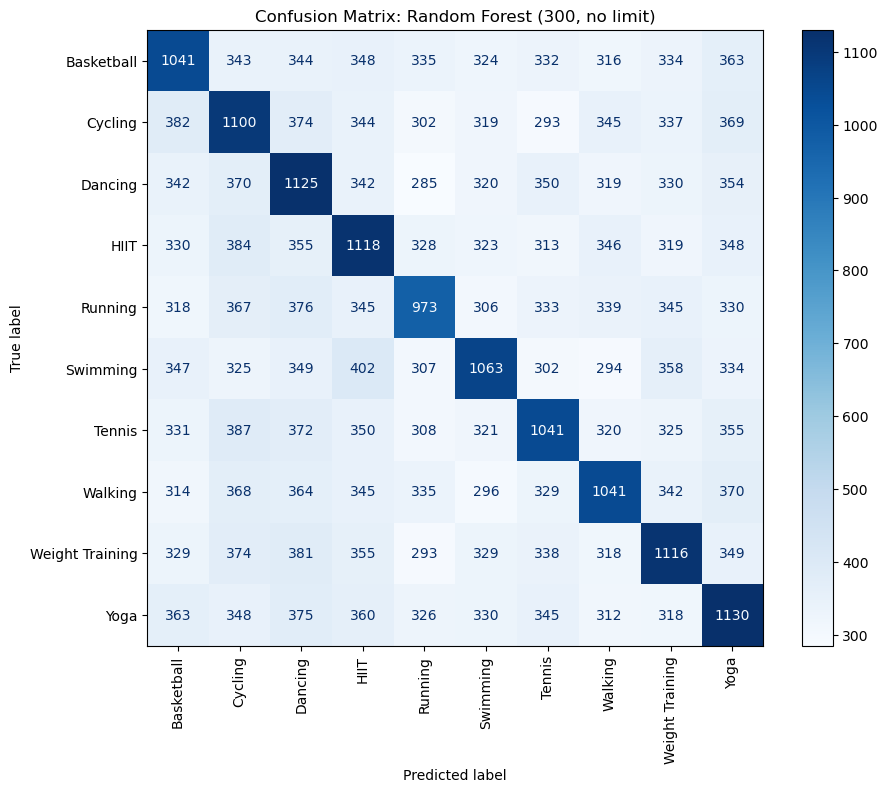

In [7]:
# Visualize the results for the best model (Lecture 15)
from sklearn.metrics import ConfusionMatrixDisplay

tgt_pred = best_model.predict(ftrs_val)
cm = metrics.confusion_matrix(tgt_val, tgt_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

In [ ]:
# ==========================================
# PART 5: Kaggle Submission
# ==========================================

print("Preparing Final Kaggle Submission...")

# 1. Apply the exact same data cleaning steps to 'test_df' to prevent mismatch errors
test_df = pd.read_csv('test_classification_dataset.csv')

test_df['health_condition'] = test_df['health_condition'].fillna('None')
test_df['intensity'] = test_df['intensity'].astype(str).str.strip().str.capitalize()
test_df['gender'] = test_df['gender'].astype(str).str.strip()
test_df['smoking_status'] = test_df['smoking_status'].astype(str).str.strip().str.capitalize()
test_df['health_condition'] = test_df['health_condition'].astype(str).str.strip().str.capitalize()

test_df['intensity'] = test_df['intensity'].map({'Low': 0, 'Medium': 1, 'High': 2}).fillna(0)
test_df['gender'] = test_df['gender'].map({'M': 0, 'F': 1, 'Other': 2})
test_df['smoking_status'] = test_df['smoking_status'].map({'Never': 0, 'Former': 1, 'Current': 2})
test_df['health_condition'] = test_df['health_condition'].map({'None': 0, 'Asthma': 1, 'Diabetes': 2, 'Hypertension': 3})

# 2. Recreate the exact same engineered features used for training
test_df['bmi'] = test_df['weight_kg'] / ((test_df['height_cm'] / 100) ** 2)
parsed_test_dates = pd.to_datetime(test_df['date'])
test_df['month'] = parsed_test_dates.dt.month
test_df['day'] = parsed_test_dates.dt.day

# Heart-rate and effort features
test_df['hr_push'] = test_df['avg_heart_rate'] - test_df['resting_heart_rate']
test_df['steps_per_minute'] = test_df['daily_steps'] / test_df['duration_minutes']
test_df['total_effort'] = test_df['duration_minutes'] * test_df['intensity']

# Calendar features
test_df['day_of_week'] = parsed_test_dates.dt.dayofweek
test_df['week_of_year'] = parsed_test_dates.dt.isocalendar().week.astype(int)
test_df['day_of_year'] = parsed_test_dates.dt.dayofyear

# Blood pressure features
test_df['bp_ratio'] = test_df['blood_pressure_systolic'] / test_df['blood_pressure_diastolic']
test_df['map_bp'] = (test_df['blood_pressure_systolic'] + 2 * test_df['blood_pressure_diastolic']) / 3
test_df['pulse_pressure'] = test_df['blood_pressure_systolic'] - test_df['blood_pressure_diastolic']

# Additional physiological ratios
test_df['hr_reserve_frac'] = test_df['hr_push'] / (220 - test_df['age'] - test_df['resting_heart_rate'])
test_df['total_movement'] = test_df['daily_steps'] * test_df['duration_minutes']

# Demographic grouping
test_df['age_decade'] = test_df['age'] // 10
test_df['has_health_condition'] = (test_df['health_condition'] > 0).astype(int)

ftrs_test_final = test_df[selected_features].copy()
# Handle division by zero or infs created during test feature engineering
ftrs_test_final = ftrs_test_final.replace([np.inf, -np.inf], np.nan)
ftrs_test_final = ftrs_test_final.apply(pd.to_numeric, errors='coerce')
ftrs_test_final = ftrs_test_final.fillna(ftrs.mean())

# 3. Refit the best model on the full labeled dataset before final prediction
print(f"Refitting final model using: {best_model_name}")
best_model.fit(ftrs, tgt)

# 4. Predict the activity types for the Kaggle test set
final_predictions = best_model.predict(ftrs_test_final)

# 5. Format the predictions into a dataframe matching Kaggle's expected format
submission_df = test_df[['row_id']].copy()
submission_df['activity_type'] = final_predictions

# 6. Validate submission
print(f"\nSubmission shape: {submission_df.shape}")
print(f"Missing values: {submission_df.isnull().sum().sum()}")
print(f"Unique predictions: {submission_df['activity_type'].nunique()}")
print(f"Prediction distribution:\n{submission_df['activity_type'].value_counts()}")

# 7. Save to CSV
submission_filename = 'final_submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"\nSuccess! Saved Kaggle predictions to '{submission_filename}'.")
display(submission_df.head())

Preparing Final Kaggle Submission...
Refitting final model using: Random Forest (300, no limit)

Submission shape: (137541, 2)
Missing values: 0
Unique predictions: 10
Prediction distribution:
activity_type
HIIT               14412
Yoga               14264
Cycling            14230
Dancing            14126
Walking            13726
Basketball         13708
Weight Training    13654
Tennis             13522
Swimming           13165
Running            12734
Name: count, dtype: int64

Success! Saved Kaggle predictions to 'final_submission.csv'.


,row_id,activity_type
0,13710,Weight Training
1,416417,Basketball
2,172457,Swimming
3,149911,Basketball
4,397070,Walking
